# Chapter 3. Statistial Experiments and Significance Testing

statistical significance, t-tests, or p-values, it is typi‐ cally in the context of the classical statistical inference. The term inference reflects the intention to apply the experiment results, which involve a limited set of data, to a larger process or population.

In [42]:
import random
import matplotlib.pylab as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [43]:
# URL Datasets
URL_WEB_PAGE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/web_page_data.csv"
URL_FOUR_SESSIONS = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/four_sessions.csv"
URL_CLICK_RATES = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/click_rates.csv"
URL_IMANISHI = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/imanishi_data.csv"

# Load Data
session_times = pd.read_csv(URL_WEB_PAGE)
four_sessions = pd.read_csv(URL_FOUR_SESSIONS)
click_rate = pd.read_csv(URL_CLICK_RATES)
imanishi = pd.read_csv(URL_IMANISHI)

## A/B Testing
An A/B test is an experiment with two groups to establish which of two treatments, products, procedures, or the like is superior.

In [44]:
session_times.Time = 100 * session_times.Time

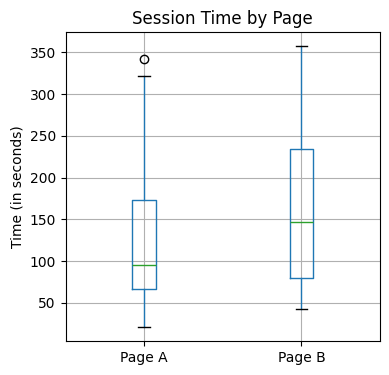

In [45]:
fig, ax = plt.subplots(figsize=(4, 4))
session_times.boxplot(by="Page", column="Time", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Time (in seconds)")
plt.suptitle("")
plt.title("Session Time by Page")
plt.tight_layout()
plt.show()

indicates that page B leads to longer sessions than page A. Page B has session times that are greater than those of page A by 35.67 seconds, on average. The question is whether this difference is within the range of what random chance might produce, i.e., is statistically significant. One way to answer this is to apply a permutation test—combine all the session times together and then repeatedly shuffle and divide them into groups of 21 (recall that nA = 21 for page A) and 15 (nB = 15 for page B).

In [46]:
mean_a = session_times[session_times.Page == "Page A"].Time.mean()
mean_b = session_times[session_times.Page == "Page B"].Time.mean()
mean_diff = mean_b - mean_a
print(f"Observed Mean Difference (Page B - Page A): {mean_diff:.2f} seconds")

Observed Mean Difference (Page B - Page A): 35.67 seconds


In [47]:
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()


nA = session_times[session_times.Page == "Page A"].shape[0]
nB = session_times[session_times.Page == "Page B"].shape[0]

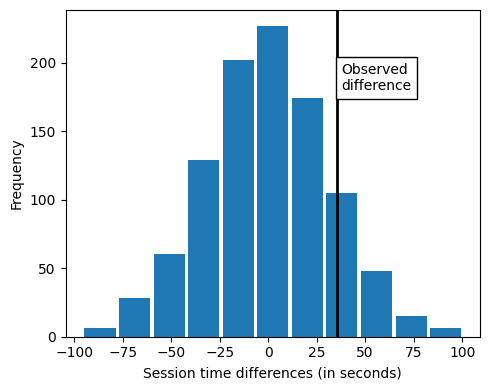

In [48]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

# Plot Distribusi Permutasi Waktu Sesi
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_diff, color="black", lw=2)
ax.text(mean_diff + 2, 180, "Observed\ndifference", bbox={"facecolor": "white"})
ax.set_xlabel("Session time differences (in seconds)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [49]:
# p-value dari Permutation Test
perm_diffs_arr = np.array(perm_diffs)
p_val_perm = np.mean(perm_diffs_arr > mean_diff)
print(
    f"Permutation Test p-value (Session Time): {p_val_perm:.4f} (atau {p_val_perm * 100:.2f}%)"
)

Permutation Test p-value (Session Time): 0.1210 (atau 12.10%)



Observed Conversion Rate Difference: 0.0368%


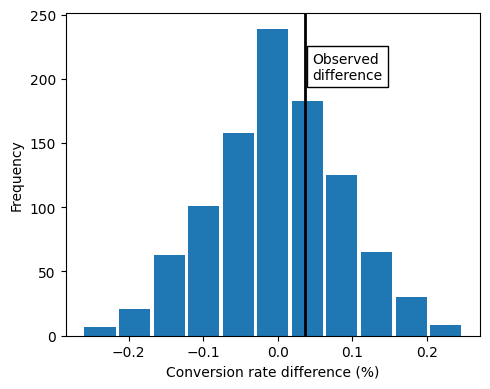

In [50]:
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f"\nObserved Conversion Rate Difference: {obs_pct_diff:.4f}%")

conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

random.seed(1)
perm_diffs_conv = [
    100 * perm_fun(conversion, 23739, 22588) for _ in range(1000)
]

# Plot Distribusi Permutasi Konversi
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(perm_diffs_conv, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color="black", lw=2)
ax.text(
    obs_pct_diff + 0.01,
    200,
    "Observed\ndifference",
    bbox={"facecolor": "white"},
)
ax.set_xlabel("Conversion rate difference (%)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [51]:
p_val_conv = np.mean([diff > obs_pct_diff for diff in perm_diffs_conv])
print(f"Permutation Test p-value (Conversion): {p_val_conv:.4f}")

Permutation Test p-value (Conversion): 0.3320


In [52]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2_stat, p_val_chi2, df, _ = stats.chi2_contingency(survivors)
print(
    f"Chi-Square Single-sided p-value (Conversion): {p_val_chi2 / 2:.4f}"
)

Chi-Square Single-sided p-value (Conversion): 0.3498


In [53]:
res_ttest = stats.ttest_ind(
    session_times[session_times.Page == "Page A"].Time,
    session_times[session_times.Page == "Page B"].Time,
    equal_var=False,
)
print(
    f"Scipy t-Test Single-sided p-value: {res_ttest.pvalue / 2:.4f}"
)

Scipy t-Test Single-sided p-value: 0.1408


In [54]:
tstat, pvalue_sm, df_sm = sm.stats.ttest_ind(
    session_times[session_times.Page == "Page A"].Time,
    session_times[session_times.Page == "Page B"].Time,
    usevar="unequal",
    alternative="smaller",
)
print(f"Statsmodels t-Test p-value (Alternative: smaller): {pvalue_sm:.4f}\n")

Statsmodels t-Test p-value (Alternative: smaller): 0.1408



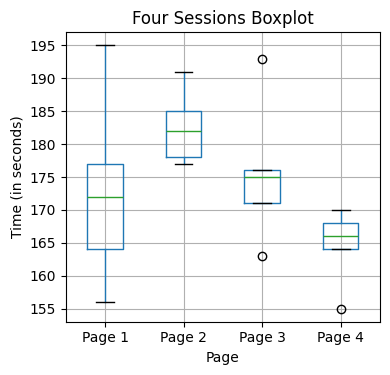

In [55]:
fig, ax = plt.subplots(figsize=(4, 4))
four_sessions.boxplot(by="Page", column="Time", ax=ax)
ax.set_xlabel("Page")
ax.set_ylabel("Time (in seconds)")
plt.suptitle("")
plt.title("Four Sessions Boxplot")
plt.tight_layout()
plt.show()

In [56]:
observed_variance = four_sessions.groupby("Page").mean().var().iloc[0]
print(f"Observed Means: {four_sessions.groupby('Page').mean().values.ravel()}")
print(f"Observed Variance between group means: {observed_variance:.4f}")


# Permutation Test untuk Variansi ANOVA
def perm_test_anova(df):
    df_copy = df.copy()
    df_copy["Time"] = np.random.permutation(df_copy["Time"].values)
    return df_copy.groupby("Page").mean().var().iloc[0]

Observed Means: [172.8 182.6 175.6 164.6]
Observed Variance between group means: 55.4267


The observed variance (55.43) is significantly higher than the permutation variance (16.71). This indicates that in the original data, there is a greater difference in the average time between pages than what would be expected to happen by chance.

Permutation ANOVA p-value: 0.0790


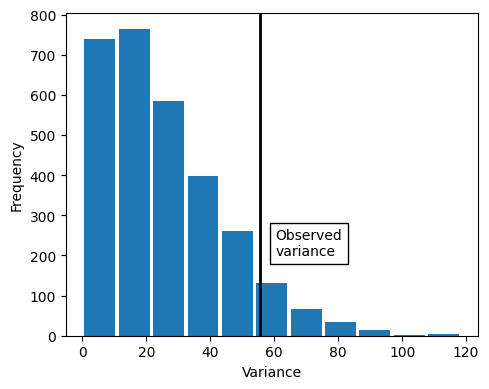

In [57]:
random.seed(1)
perm_variance = [perm_test_anova(four_sessions) for _ in range(3000)]
p_val_anova_perm = np.mean([var > observed_variance for var in perm_variance])
print(
    f"Permutation ANOVA p-value: {p_val_anova_perm:.4f}"
)

# Histograms Hasil Permutasi ANOVA
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color="black", lw=2)
ax.text(
    observed_variance + 5,
    200,
    "Observed\nvariance",
    bbox={"facecolor": "white"},
)
ax.set_xlabel("Variance")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

A p-value of 0.08 is close to the typical significance threshold of 0.05, which may indicate the presence of a trend or a small difference that isn't strong enough to be conclusively detected with the current data.

In [58]:
model = smf.ols("Time ~ Page", data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
print("=== Classical ANOVA Table (statsmodels) ===")
print(aov_table)

=== Classical ANOVA Table (statsmodels) ===
            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


The stats.f_oneway function from the scipy.stats module is used to perform One-Way ANOVA (Analysis of Variance). One-Way ANOVA is a statistical method that tests whether there are significant differences between the means of three or more independent (unrelated) groups.



In [59]:
res_f = stats.f_oneway(
    four_sessions[four_sessions.Page == "Page 1"].Time,
    four_sessions[four_sessions.Page == "Page 2"].Time,
    four_sessions[four_sessions.Page == "Page 3"].Time,
    four_sessions[four_sessions.Page == "Page 4"].Time,
)
print(f"\nScipy One-Way ANOVA F-Statistic: {res_f.statistic:.4f}")
print(f"Scipy One-Way ANOVA p-value: {res_f.pvalue:.4f}\n")


Scipy One-Way ANOVA F-Statistic: 2.7398
Scipy One-Way ANOVA p-value: 0.0776



One-Way ANOVA is used when you have one independent categorical variable with two or more levels (groups) and one dependent continuous variable. It helps determine if at least one group mean is statistically different from the others.

In [60]:
clicks = click_rate.pivot(index="Click", columns="Headline", values="Rate")
print("=== Contingency Table (Clicks vs Headline) ===")
print(clicks)

=== Contingency Table (Clicks vs Headline) ===
Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [61]:
# Table 3-5
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


We can test with this resampling algorithm:
1. Constitute a box with 34 ones (clicks) and 2,966 zeros (no clicks).
2. Shuffle, take three separate samples of 1,000, and count the clicks in each.
3. Find the squared differences between the shuffled counts and the expected counts and sum them.
4. Repeat steps 2 and 3, say, 1,000 times.
5. How often does the resampled sum of squared deviations exceed the observed? That’s the p-value.

In [62]:
box = [1] * 34
box.extend([0] * 2966)


def calc_chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append(
            [(observe - expect) ** 2 / expect for observe in row]
        )
    return np.sum(pearson_residuals)


expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]

chi2observed = calc_chi2(clicks.values, expected)


def perm_chi2_fun(box_list):
    random.shuffle(box_list)
    sample_clicks = [
        sum(box_list[0:1000]),
        sum(box_list[1000:2000]),
        sum(box_list[2000:3000]),
    ]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return calc_chi2([sample_clicks, sample_noclicks], expected)


random.seed(1)
perm_chi2 = [perm_chi2_fun(box) for _ in range(2000)]
resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)

print(f"\nObserved Chi2: {chi2observed:.4f}")
print(f"Resampled Chi2 p-value: {resampled_p_value:.4f}")


Observed Chi2: 1.6659
Resampled Chi2 p-value: 0.4655


In [63]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


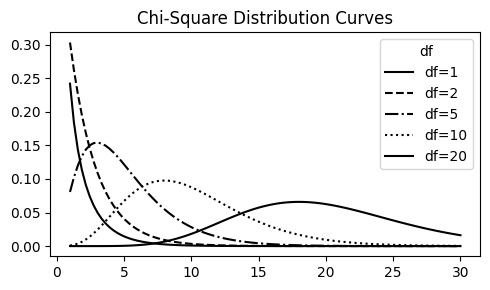

In [64]:
x_val = [1 + i * (30 - 1) / 99 for i in range(100)]
chi_df = pd.DataFrame(
    {
        "x": x_val,
        "chi_1": stats.chi2.pdf(x_val, df=1),
        "chi_2": stats.chi2.pdf(x_val, df=2),
        "chi_5": stats.chi2.pdf(x_val, df=5),
        "chi_10": stats.chi2.pdf(x_val, df=10),
        "chi_20": stats.chi2.pdf(x_val, df=20),
    }
)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(chi_df.x, chi_df.chi_1, color="black", linestyle="-", label="df=1")
ax.plot(chi_df.x, chi_df.chi_2, color="black", linestyle="--", label="df=2")
ax.plot(chi_df.x, chi_df.chi_5, color="black", linestyle="-.", label="df=5")
ax.plot(chi_df.x, chi_df.chi_10, color="black", linestyle=":", label="df=10")
ax.plot(chi_df.x, chi_df.chi_20, color="black", linestyle="-", label="df=20")
ax.legend(title="df")
ax.set_title("Chi-Square Distribution Curves")
plt.tight_layout()
plt.show()

### Sample Size
Definition: The number of individuals or
observations collected in a study.
Importance:
Accuracy: Larger samples better represent the entire population.
Variability: Reduces the impact of random fluctuations.
Example: To find the average height of students, measuring 100 students gives a more accurate result than measuring just 5.

### Power
Definition: The probability that a statistical test will detect an effect or difference if it truly exists.
Importance:
Avoiding Type II Errors: High power decreases the chance of missing a real effect.
Reliable Results: Ensures the study's findings are trustworthy.
Example: When testing a new drug, high power means there's a good chance of proving the drug is more effective if it actually is.

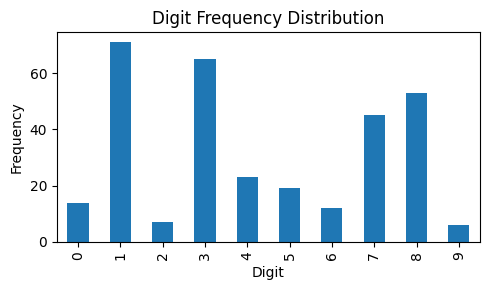

In [65]:
imanishi.columns = [c.strip() for c in imanishi.columns]

fig, ax = plt.subplots(figsize=(5, 3))
imanishi.plot.bar(x="Digit", y=["Frequency"], legend=False, ax=ax)
ax.set_xlabel("Digit")
ax.set_ylabel("Frequency")
ax.set_title("Digit Frequency Distribution")
plt.tight_layout()
plt.show()

In [66]:
effect_size_1 = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
sample_size_1 = analysis.solve_power(
    effect_size=effect_size_1, alpha=0.05, power=0.8, alternative="larger"
)
print(f"Required Sample Size (Small Effect 1.1% -> 1.21%): {sample_size_1:.2f}")

Required Sample Size (Small Effect 1.1% -> 1.21%): 116602.39


In [67]:
effect_size_2 = sm.stats.proportion_effectsize(0.0165, 0.011)
sample_size_2 = analysis.solve_power(
    effect_size=effect_size_2, alpha=0.05, power=0.8, alternative="larger"
)
print(f"Required Sample Size (Larger Effect 1.1% -> 1.65%): {sample_size_2:.2f}")

Required Sample Size (Larger Effect 1.1% -> 1.65%): 5488.41
